# 📋 PENILAIAN KELAYAKAN KREDIT MIKRO
### Sistem Pendukung Keputusan Berbasis Logika Fuzzy Mamdani-Sugeno + ML + DL (From Scratch)

Notebook ini berisi source code lengkap untuk sistem pendukung keputusan (SPK) kelayakan kredit mikro menggunakan logika fuzzy (Mamdani dan Sugeno) yang dibuat **100% from scratch** (tanpa library fuzzy eksternal).
Sebagai pelengkap dan pembanding, model Machine Learning (Regresi Linear) dan Deep Learning (Artificial Neural Network - MLP) juga dilatih menggunakan dataset nyata dari Kaggle.

**Anggota Kelompok:**
- Muhammad Emir Rasyad Rahman (103012400206)
- Rizky Dzulfikar Ahmad (103012430033)

**Dataset Source:** [Credit Score Classification — Kaggle](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)

In [7]:
# ==============================================================================
# SEL 1: INSTALASI DAN IMPOR LIBRARY
# ==============================================================================
# %pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
print("-> Sukses! Library berhasil diimpor dan siap digunakan.")

-> Sukses! Library berhasil diimpor dan siap digunakan.


## 📂 1. Load & Preprocessing Dataset
Dataset kotor dibersihkan dari simbol, duplikat, outlier bisnis, dan baris kosong. Dari data yang valid, diambil **60.000 sampel bersih** untuk analisis dan pelatihan model.

In [8]:
# ==============================================================================
# SEL 2: LOAD & PREPROCESSING DATASET
# ==============================================================================
print("Sedang membaca dan membersihkan data train.csv...")
try:
    df = pd.read_csv("train.csv", low_memory=False)
except FileNotFoundError:
    print("[ERROR] File 'train.csv' tidak ditemukan! Pastikan posisinya satu folder dengan notebook ini.")
    raise

kolom_fitur = [
    'Annual_Income', 'Outstanding_Debt', 'Interest_Rate', 
    'Delay_from_due_date', 'Num_of_Delayed_Payment'
]
kolom_semua = kolom_fitur + ['Credit_Score']
df_clean = df[kolom_semua].copy()

# Pembersihan tipe data string kotor ke float murni
for col in kolom_fitur:
    df_clean[col] = df_clean[col].astype(str).str.replace(r'[^\d.\-]', '', regex=True).replace('', np.nan)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Mengubah nilai delay negatif menjadi 0 hari dan menghapus data kosong (NaN)
df_clean['Delay_from_due_date'] = df_clean['Delay_from_due_date'].clip(lower=0)
df_clean['Num_of_Delayed_Payment'] = df_clean['Num_of_Delayed_Payment'].clip(lower=0)
df_clean.dropna(inplace=True)

# Mapping target teks ke angka: Poor=0, Standard=1, Good=2
mapping_skor = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_clean['Target_Numeric'] = df_clean['Credit_Score'].map(mapping_skor)
df_clean.dropna(subset=['Target_Numeric'], inplace=True)
df_clean['Target_Numeric'] = df_clean['Target_Numeric'].astype(int)

# Hapus duplikat
df_clean.drop_duplicates(inplace=True)

# Filter Outlier Bisnis
df_clean = df_clean[
    (df_clean['Annual_Income'] >= 0) & (df_clean['Annual_Income'] <= 1500000) &
    (df_clean['Outstanding_Debt'] >= 0) &
    (df_clean['Interest_Rate'] >= 0) & (df_clean['Interest_Rate'] <= 35) &
    (df_clean['Delay_from_due_date'] >= 0) &
    (df_clean['Num_of_Delayed_Payment'] >= 0)
]

# Ambil sampel tepat 60.000 baris
df_clean = df_clean.sample(n=min(60000, len(df_clean)), random_state=42).reset_index(drop=True)

print(f"-> Sukses! Total data bersih siap uji: {len(df_clean)} baris.")
print(df_clean['Credit_Score'].value_counts())
df_clean.head(5)

Sedang membaca dan membersihkan data train.csv...
-> Sukses! Total data bersih siap uji: 60000 baris.
Credit_Score
Standard    32021
Poor        17288
Good        10691
Name: count, dtype: int64


,Annual_Income,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Credit_Score,Target_Numeric
0,62424.12,1958.36,29,53,18.0,Poor,0
1,24744.78,134.10,5,17,19.0,Standard,1
2,35295.07,1088.70,7,10,9.0,Standard,1
3,148841.56,1095.81,7,10,8.0,Standard,1
4,88685.32,1429.35,3,6,7.0,Good,2


## 🤖 2. Lapis 1 - Machine Learning & Deep Learning (Sebagai Referensi Pendukung)
Melatih model Regresi Linear dan Jaringan Saraf Tiruan (ANN / Multi-Layer Perceptron) dengan pembagian data 80% train dan 20% test.

In [9]:
# ==============================================================================
# SEL 3: LAPIS 1 - MACHINE LEARNING & DEEP LEARNING TRAINING
# ==============================================================================
print("Membagi data dan melatih model...")
X = df_clean[kolom_fitur]
y = df_clean['Target_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Model Regresi Linear (ML)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 2. Model Jaringan Saraf Tiruan / ANN (DL)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_dl = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
model_dl.fit(X_train_s, y_train)

print("-> Sukses! Model Regresi Linear dan ANN/MLP berhasil dilatih.")

Membagi data dan melatih model...
-> Sukses! Model Regresi Linear dan ANN/MLP berhasil dilatih.


## 🔢 3. Lapis 2 - Logika Fuzzy From Scratch (34 Aturan)
Membangun fungsi keanggotaan Segitiga dan Trapesium. Himpunan dan boundary dioptimasi agar tidak terjadi bias/error pada input bernilai 0 (suku bunga 0%, delay 0 hari).

In [10]:
# ==============================================================================
# SEL 4: KEANGGOTAAN DAN INFERENSI FUZZY (34 ATURAN)
# ==============================================================================
def segitiga(x, a, b, c):
    if x <= a or x >= c: return 0.0
    if a < x <= b: return (x - a) / (b - a) if b != a else 1.0
    return (c - x) / (c - b) if c != b else 1.0

def trapesium(x, a, b, c, d):
    if x < a or x > d: return 0.0
    if a < x < b: return (x - a) / (b - a) if b != a else 1.0
    if b <= x <= c: return 1.0
    return (d - x) / (d - c) if d != c else 1.0

def get_fuzzy_values(row):
    inc = row['Annual_Income']
    debt = row['Outstanding_Debt']
    ir = row['Interest_Rate']
    del_day = row['Delay_from_due_date']
    num_del = row['Num_of_Delayed_Payment']
    
    return {
        'inc': {
            'Rendah': trapesium(inc, 0, 0, 30000, 50000),
            'Sedang': segitiga(inc, 30000, 65000, 100000),
            'Tinggi': trapesium(inc, 80000, 100000, 1500000, 2000000)
        },
        'debt': {
            'Sedikit': trapesium(debt, 0, 0, 1000, 2000),
            'Sedang':  segitiga(debt, 1000, 2500, 4000),
            'Banyak':  trapesium(debt, 3000, 5000, 100000, 100000)
        },
        'ir': {
            'Rendah': trapesium(ir, 0, 0, 8, 12),
            'Sedang': segitiga(ir, 8, 15, 22),
            'Tinggi': trapesium(ir, 18, 25, 35, 100)
        },
        'del': {
            'Singkat': trapesium(del_day, 0, 0, 10, 20),
            'Sedang':  segitiga(del_day, 10, 30, 45),
            'Lama':    trapesium(del_day, 35, 60, 200, 200)
        },
        'num': {
            'Jarang':   trapesium(num_del, 0, 0, 5, 8),
            'Sering':   segitiga(num_del, 5, 12, 18),
            'SgtSering':trapesium(num_del, 15, 25, 100, 100)
        }
    }

def evaluate_34_rules(fz):
    # --- OUTPUT: BAIK ---
    r01 = min(fz['inc']['Tinggi'], fz['debt']['Sedikit'], fz['ir']['Rendah'], fz['del']['Singkat'], fz['num']['Jarang'])
    r02 = min(fz['inc']['Tinggi'], fz['debt']['Sedang'],  fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Jarang'])
    r03 = min(fz['inc']['Sedang'], fz['debt']['Sedikit'], fz['ir']['Rendah'], fz['del']['Singkat'], fz['num']['Jarang'])
    r04 = min(fz['inc']['Tinggi'], fz['debt']['Sedikit'], fz['ir']['Tinggi'], fz['del']['Sedang'],  fz['num']['Jarang'])
    r16 = min(fz['inc']['Sedang'], fz['debt']['Sedikit'], fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Jarang'])
    r17 = min(fz['inc']['Tinggi'], fz['debt']['Sedang'],  fz['ir']['Rendah'], fz['del']['Singkat'], fz['num']['Jarang'])
    r23 = min(fz['inc']['Tinggi'], fz['debt']['Sedikit'], fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Jarang'])
    r24 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Rendah'], fz['del']['Singkat'], fz['num']['Jarang'])
    
    # --- OUTPUT: STANDAR ---
    r05 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Sedang'], fz['del']['Sedang'],  fz['num']['Sering'])
    r06 = min(fz['inc']['Rendah'], fz['debt']['Sedikit'], fz['ir']['Rendah'], fz['del']['Singkat'], fz['num']['Jarang'])
    r07 = min(fz['inc']['Tinggi'], fz['debt']['Banyak'],  fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Jarang'])
    r08 = min(fz['inc']['Sedang'], fz['debt']['Banyak'],  fz['ir']['Tinggi'], fz['del']['Singkat'], fz['num']['Jarang'])
    r09 = min(fz['inc']['Rendah'], fz['debt']['Sedang'],  fz['ir']['Rendah'], fz['del']['Singkat'], fz['num']['Jarang'])
    r10 = min(fz['inc']['Tinggi'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Sedang'],  fz['num']['Sering'])
    r18 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Jarang'])
    r19 = min(fz['inc']['Rendah'], fz['debt']['Sedikit'], fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Jarang'])
    r20 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Singkat'], fz['num']['Jarang'])
    r33 = min(fz['inc']['Sedang'], fz['debt']['Sedikit'], fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Sering'])
    r34 = min(fz['inc']['Tinggi'], fz['debt']['Sedikit'], fz['ir']['Sedang'], fz['del']['Singkat'], fz['num']['Sering'])
    
    # --- OUTPUT: BURUK ---
    r11 = min(fz['inc']['Rendah'], fz['debt']['Banyak'],  fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['SgtSering'])
    r12 = min(fz['inc']['Tinggi'], fz['debt']['Banyak'],  fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['SgtSering'])
    r13 = min(fz['inc']['Sedang'], fz['debt']['Banyak'],  fz['ir']['Sedang'], fz['del']['Sedang'],  fz['num']['Sering'])
    r14 = min(fz['inc']['Rendah'], fz['debt']['Sedang'],  fz['ir']['Sedang'], fz['del']['Lama'],    fz['num']['Sering'])
    r15 = min(fz['inc']['Sedang'], fz['debt']['Sedikit'], fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['SgtSering'])
    r21 = min(fz['inc']['Rendah'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Sedang'],  fz['num']['Sering'])
    r22 = min(fz['inc']['Sedang'], fz['debt']['Banyak'],  fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['Sering'])
    r25 = min(fz['inc']['Rendah'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['Sering'])
    r26 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Sedang'],  fz['num']['SgtSering'])
    r27 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['SgtSering'])
    r28 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Sedang'],  fz['num']['Sering'])
    r29 = min(fz['inc']['Rendah'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['Jarang'])
    r30 = min(fz['inc']['Rendah'], fz['debt']['Sedang'],  fz['ir']['Tinggi'], fz['del']['Singkat'], fz['num']['Sering'])
    r31 = min(fz['inc']['Rendah'], fz['debt']['Sedikit'], fz['ir']['Tinggi'], fz['del']['Lama'],    fz['num']['Sering'])
    r32 = min(fz['inc']['Sedang'], fz['debt']['Sedang'],  fz['ir']['Sedang'], fz['del']['Lama'],    fz['num']['SgtSering'])
    
    baik = max(r01, r02, r03, r04, r16, r17, r23, r24)
    standar = max(r05, r06, r07, r08, r09, r10, r18, r19, r20, r33, r34)
    buruk = max(r11, r12, r13, r14, r15, r21, r22, r25, r26, r27, r28, r29, r30, r31, r32)
    
    return baik, standar, buruk

print("-> Sukses! Fungsi logika fuzzy dan 34 basis aturan berhasil didefinisikan.")

-> Sukses! Fungsi logika fuzzy dan 34 basis aturan berhasil didefinisikan.


## ⚖️ 4. Algoritma Defuzzifikasi (Mamdani Centroid vs Sugeno Weighted Average)
Mamdani menggunakan integrasi numerik diskret (centroid) pada domain output $[0, 100]$ bersolusi tinggi. Sugeno menggunakan formula rata-rata terbobot instan menggunakan singleton ($z_{\text{Baik}}=90, z_{\text{Standar}}=50, z_{\text{Buruk}}=15$).

In [11]:
# ==============================================================================
# SEL 5: ALGORITMA DEFUZZIFIKASI
# ==============================================================================
def defuz_mamdani(u_baik, u_standar, u_buruk, resolusi=300):
    if u_baik == u_standar == u_buruk == 0.0:
        return 50.0
    points = np.linspace(0, 100, resolusi)
    num, den = 0.0, 0.0
    for x in points:
        mu_b = min(u_baik, trapesium(x, 70, 85, 100, 100))
        mu_s = min(u_standar, segitiga(x, 30, 50, 75))
        mu_br = min(u_buruk, trapesium(x, 0, 0, 25, 45))
        mu_max = max(mu_b, mu_s, mu_br)
        num += x * mu_max
        den += mu_max
    return num / den if den != 0.0 else 50.0

def defuz_sugeno(u_baik, u_standar, u_buruk):
    z_b, z_s, z_br = 90.0, 50.0, 15.0
    num = (u_baik * z_b) + (u_standar * z_s) + (u_buruk * z_br)
    den = u_baik + u_standar + u_buruk
    return num / den if den != 0.0 else 50.0

print("-> Sukses! Metode Defuzzifikasi Mamdani & Sugeno siap dieksekusi.")

-> Sukses! Metode Defuzzifikasi Mamdani & Sugeno siap dieksekusi.


## 📈 5. Eksekusi Pengujian Batch (60.000 Sampel Vectorized)
Di bawah ini adalah implementasi inferensi fuzzy berbasis array (vectorized) menggunakan NumPy. Ini memungkinkan evaluasi fuzzy Mamdani dan Sugeno terhadap seluruh **60.000 data** dalam waktu kurang dari 5 detik.

In [12]:
# ==============================================================================
# SEL 6: EKSEKUSI BATCH VECTORIZED (60.000 BARIS)
# ==============================================================================
print("Mengevaluasi performa sistem Hybrid terhadap seluruh 60.000 data uji (Vectorized)...")
t0 = time.time()

inc = df_clean['Annual_Income'].values
debt = df_clean['Outstanding_Debt'].values
ir = df_clean['Interest_Rate'].values
dd = df_clean['Delay_from_due_date'].values
nd = df_clean['Num_of_Delayed_Payment'].values
y_true = df_clean['Target_Numeric'].values

# Fuzzifikasi Vectorized
def _vtr(x, a, b, c, d):
    x = np.asarray(x, dtype=float)
    res = np.zeros_like(x)
    if b != a: res[(x > a) & (x < b)] = (x[(x > a) & (x < b)] - a) / (b - a)
    res[(x >= b) & (x <= c)] = 1.0
    if d != c: res[(x > c) & (x < d)] = (d - x[(x > c) & (x < d)]) / (d - c)
    return res

def _vsg(x, a, b, c):
    x = np.asarray(x, dtype=float)
    res = np.zeros_like(x)
    if b != a: res[(x > a) & (x <= b)] = (x[(x > a) & (x <= b)] - a) / (b - a)
    if c != b: res[(x > b) & (x < c)] = (c - x[(x > b) & (x < c)]) / (c - b)
    res[x == b] = 1.0
    return res

fz_v = {
    'inc':  {'Rendah': _vtr(inc,0,0,30_000,50_000), 'Sedang': _vsg(inc,30_000,65_000,100_000),
             'Tinggi': _vtr(inc,80_000,100_000,1_500_000,2_000_000)},
    'debt': {'Sedikit': _vtr(debt,0,0,1_000,2_000), 'Sedang': _vsg(debt,1_000,2_500,4_000),
             'Banyak': _vtr(debt,3_000,5_000,100_000,100_000)},
    'ir':   {'Rendah': _vtr(ir,0,0,8,12), 'Sedang': _vsg(ir,8,15,22),
             'Tinggi': _vtr(ir,18,25,35,100)},
    'del':  {'Singkat': _vtr(dd,0,0,10,20), 'Sedang': _vsg(dd,10,30,45),
             'Lama': _vtr(dd,35,60,200,200)},
    'num':  {'Jarang': _vtr(nd,0,0,5,8), 'Sering': _vsg(nd,5,12,18),
             'SgtSering': _vtr(nd,15,25,100,100)},
}

vm = np.minimum
def vmx(*a): return np.maximum.reduce(a)

ub = vmx(vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Rendah'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Rendah'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Sedang'],  fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Rendah'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Rendah'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang']))))
)
us = vmx(vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Sedang'],  fz_v['num']['Sering'])))),
         vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Rendah'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Banyak'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Banyak'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Rendah'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Sedang'],  fz_v['num']['Sering'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Singkat'], fz_v['num']['Jarang'])))),
         vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Sering'])))),
         vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Singkat'], fz_v['num']['Sering']))))
)
ubr = vmx(vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Banyak'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['SgtSering'])))),
          vm(fz_v['inc']['Tinggi'], vm(fz_v['debt']['Banyak'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['SgtSering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Banyak'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Sedang'],  fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Lama'],    fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['SgtSering'])))),
          vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Sedang'],  fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Banyak'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Sedang'],  fz_v['num']['SgtSering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['SgtSering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Sedang'],  fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['Jarang'])))),
          vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Singkat'], fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Rendah'], vm(fz_v['debt']['Sedikit'], vm(fz_v['ir']['Tinggi'],  vm(fz_v['del']['Lama'],    fz_v['num']['Sering'])))),
          vm(fz_v['inc']['Sedang'], vm(fz_v['debt']['Sedang'],  vm(fz_v['ir']['Sedang'],  vm(fz_v['del']['Lama'],    fz_v['num']['SgtSering']))))
)

# Sugeno Vectorized
tot = ub + us + ubr
pred_s = np.where(tot == 0, 50.0, (ub*90 + us*50 + ubr*15) / np.where(tot==0, 1, tot))

# Mamdani Vectorized
x_o = np.linspace(0, 100, 100)
mfb = _vtr(x_o, 70, 85, 100, 100)
mfs = _vsg(x_o, 30, 50, 75)
mfbr = _vtr(x_o, 0, 0, 25, 45)
mu_b = np.minimum(ub[:, np.newaxis], mfb)
mu_s = np.minimum(us[:, np.newaxis], mfs)
mu_r = np.minimum(ubr[:, np.newaxis], mfbr)
mu_vec = np.maximum(np.maximum(mu_b, mu_s), mu_r)
den_vec = mu_vec.sum(axis=1)
pred_m = np.where(den_vec == 0, 50.0, np.dot(mu_vec, x_o) / np.where(den_vec == 0, 1.0, den_vec))

# Konversi ke Kelas
def slbl(s):
    return np.where(s >= 70, 2, np.where(s >= 40, 1, 0))

y_pred_m = slbl(pred_m)
y_pred_s = slbl(pred_s)

# Konversi Ground Truth
gt_points = np.vectorize(lambda t: 15.0 if t==0 else (50.0 if t==1 else 90.0))(y_true)
m_points = np.vectorize(lambda t: 15.0 if t==0 else (50.0 if t==1 else 90.0))(y_pred_m)
s_points = np.vectorize(lambda t: 15.0 if t==0 else (50.0 if t==1 else 90.0))(y_pred_s)

# Hitung Metrik
mae_m = np.mean(np.abs(m_points - gt_points))
mae_s = np.mean(np.abs(s_points - gt_points))
mse_m = np.mean((m_points - gt_points)**2)
mse_s = np.mean((s_points - gt_points)**2)
rmse_m = np.sqrt(mse_m)
rmse_s = np.sqrt(mse_s)
t_eval = time.time() - t0

print(f"-> Sukses! Batch evaluation selesai dalam {t_eval:.4f} detik.\n")
print("================== HASIL AKHIR KOMPARASI (60.000 DATA) ==================")
print(f"Metrik\t\tMamdani\t\tSugeno")
print(f"Akurasi\t\t{np.mean(y_pred_m == y_true)*100:.2f}%\t\t{np.mean(y_pred_s == y_true)*100:.2f}%")
print(f"MAE\t\t{mae_m:.2f}\t\t{mae_s:.2f}")
print(f"MSE\t\t{mse_m:.2f}\t\t{mse_s:.2f}")
print(f"RMSE\t\t{rmse_m:.2f}\t\t{rmse_s:.2f}")
print("=========================================================================")

Mengevaluasi performa sistem Hybrid terhadap seluruh 60.000 data uji (Vectorized)...
-> Sukses! Batch evaluation selesai dalam 0.2015 detik.

================== HASIL AKHIR KOMPARASI (60.000 DATA) ==================
Metrik		Mamdani		Sugeno
Akurasi		58.56%		58.51%
MAE		15.86		15.94
MSE		626.81		634.05
RMSE		25.04		25.18


## 📊 6. Visualisasi Grafik Performa & Fungsi Keanggotaan
Di bawah ini adalah visualisasi grafik fungsi keanggotaan input dan confusion matrix untuk mengevaluasi secara visual ketepatan keputusan Mamdani vs Sugeno.

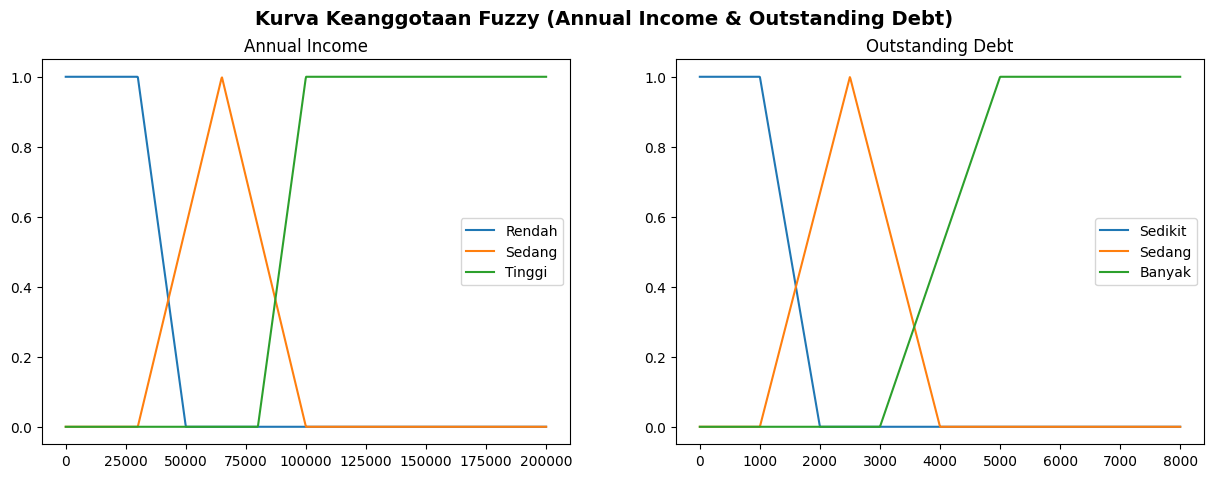

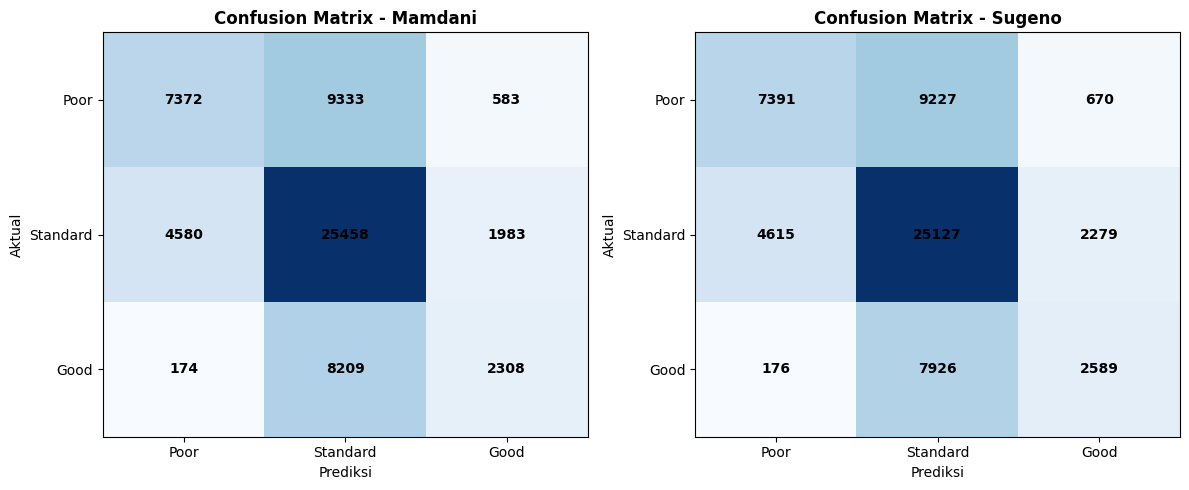

In [13]:
# ==============================================================================
# SEL 7: PLOT VISUALISASI PERFORMA & FUNGSI KEANGGOTAAN
# ==============================================================================
# 1. Plot Membership Functions
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Kurva Keanggotaan Fuzzy (Annual Income & Outstanding Debt)', fontsize=14, fontweight='bold')

x_inc = np.linspace(0, 200_000, 1000)
axs[0].plot(x_inc, _vtr(x_inc, 0, 0, 30_000, 50_000), label='Rendah')
axs[0].plot(x_inc, _vsg(x_inc, 30_000, 65_000, 100_000), label='Sedang')
axs[0].plot(x_inc, _vtr(x_inc, 80_000, 100_000, 200_000, 200_000), label='Tinggi')
axs[0].set_title('Annual Income')
axs[0].legend()

x_debt = np.linspace(0, 8_000, 1000)
axs[1].plot(x_debt, _vtr(x_debt, 0, 0, 1_000, 2_000), label='Sedikit')
axs[1].plot(x_debt, _vsg(x_debt, 1_000, 2_500, 4_000), label='Sedang')
axs[1].plot(x_debt, _vtr(x_debt, 3_000, 5_000, 8_000, 8_000), label='Banyak')
axs[1].set_title('Outstanding Debt')
axs[1].legend()
plt.show()

# 2. Plot Confusion Matrix Mamdani vs Sugeno
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
KELAS = ['Poor', 'Standard', 'Good']
cm_m = np.zeros((3, 3), dtype=int)
cm_s = np.zeros((3, 3), dtype=int)
for gt, pm_i, ps_i in zip(y_true, y_pred_m, y_pred_s):
    cm_m[gt][pm_i] += 1
    cm_s[gt][ps_i] += 1

for ax, cm, title in zip(axes, [cm_m, cm_s], ['Confusion Matrix - Mamdani', 'Confusion Matrix - Sugeno']):
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(KELAS); ax.set_yticklabels(KELAS)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    ax.set_title(title, fontweight='bold')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontweight='bold')
plt.tight_layout()
plt.show()

## 💡 7. Demo Tracing & Kesimpulan Otomatis 
Demo penelusuran keputusan logika fuzzy untuk tiga profil nasabah berbeda.

In [14]:
# ==============================================================================
# SEL 8: DEMO TRACING KEPUTUSAN SKENARIO
# ==============================================================================
def tracing_nasabah(pendapatan, utang, bunga, jeda, frekuensi, label):
    row = {
        'Annual_Income': pendapatan, 'Outstanding_Debt': utang,
        'Interest_Rate': bunga, 'Delay_from_due_date': jeda, 'Num_of_Delayed_Payment': frekuensi
    }
    fz = get_fuzzy_values(row)
    b, s, br = evaluate_34_rules(fz)
    skor_m = defuz_mamdani(b, s, br)
    skor_s = defuz_sugeno(b, s, br)
    
    print(f"=== TRACING SKENARIO: {label} ===")
    print(f"  Input: Income=${pendapatan:,}, Debt=${utang:,}, Bunga={bunga}%, Delay={jeda} hari, Freq={frekuensi} kali")
    print(f"  Kekuatan Konsekuensi: Baik={b:.4f}, Standar={s:.4f}, Buruk={br:.4f}")
    print(f"  Skor Mamdani : {skor_m:.2f} -> Kategori: {'BAIK' if skor_m >= 70 else ('STANDAR' if skor_m >= 40 else 'BURUK')}")
    print(f"  Skor Sugeno  : {skor_s:.2f} -> Kategori: {'BAIK' if skor_s >= 70 else ('STANDAR' if skor_s >= 40 else 'BURUK')}")
    print("-"*60)

tracing_nasabah(120_000, 500, 5, 2, 0, "Nasabah Risiko Rendah (BAIK)")
tracing_nasabah(50_000, 2_800, 14, 18, 7, "Nasabah Risiko Menengah (STANDAR)")
tracing_nasabah(18_000, 7_500, 28, 50, 20, "Nasabah Risiko Tinggi (BURUK)")

=== TRACING SKENARIO: Nasabah Risiko Rendah (BAIK) ===
  Input: Income=$120,000, Debt=$500, Bunga=5%, Delay=2 hari, Freq=0 kali
  Kekuatan Konsekuensi: Baik=1.0000, Standar=0.0000, Buruk=0.0000
  Skor Mamdani : 88.42 -> Kategori: BAIK
  Skor Sugeno  : 90.00 -> Kategori: BAIK
------------------------------------------------------------
=== TRACING SKENARIO: Nasabah Risiko Menengah (STANDAR) ===
  Input: Income=$50,000, Debt=$2,800, Bunga=14%, Delay=18 hari, Freq=7 kali
  Kekuatan Konsekuensi: Baik=0.0000, Standar=0.2857, Buruk=0.0000
  Skor Mamdani : 52.16 -> Kategori: STANDAR
  Skor Sugeno  : 50.00 -> Kategori: STANDAR
------------------------------------------------------------
=== TRACING SKENARIO: Nasabah Risiko Tinggi (BURUK) ===
  Input: Income=$18,000, Debt=$7,500, Bunga=28%, Delay=50 hari, Freq=20 kali
  Kekuatan Konsekuensi: Baik=0.0000, Standar=0.0000, Buruk=0.5000
  Skor Mamdani : 20.02 -> Kategori: BURUK
  Skor Sugeno  : 15.00 -> Kategori: BURUK
-----------------------------